In [ ]:
# Install required packages
!pip install datasets pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datasets import load_dataset
from collections import Counter
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Packages installed and imported")

✓ Packages installed and imported


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base path - SAME FOR ALL PHASES
base_path = '/content/drive/MyDrive/CSE 941'

# Phase number - CHANGE THIS for each phase (1, 2, 3, 4, 5, or 6)
phase_num = 1  # ← CHANGE THIS

output_dir = f'{base_path}/outputs/phase{phase_num}'
plots_dir = f'{output_dir}/plots'

import os
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

print(f"✓ Working in: {base_path}")
print(f"✓ Output directory: {output_dir}")

Mounted at /content/drive
✓ Working in: /content/drive/MyDrive/CSE 941
✓ Output directory: /content/drive/MyDrive/CSE 941/outputs/phase1


In [ ]:
print("Loading Amazon Beauty 2023 from Google Drive...")

import gzip
import json
import pandas as pd
from tqdm import tqdm

# Paths in your Drive
reviews_path = '/content/drive/MyDrive/CSE 941/data/raw/All_Beauty.jsonl.gz'
meta_path = '/content/drive/MyDrive/CSE 941/data/raw/meta_All_Beauty.jsonl.gz'

# Load reviews
print("Loading reviews...")
reviews = []
with gzip.open(reviews_path, 'rt', encoding='utf-8') as f:
    for line in tqdm(f, desc="Reading reviews"):
        reviews.append(json.loads(line))

dataset = reviews
print(f"✓ Dataset loaded: {len(dataset):,} reviews")
print("\nSample review:")
print(dataset[0])

Loading Amazon Beauty 2023 from Google Drive...
Loading reviews...


Reading reviews: 701528it [00:13, 52586.04it/s]

✓ Dataset loaded: 701,528 reviews

Sample review:
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}


In [ ]:
# Convert to pandas
print("Converting to DataFrame...")

reviews_df = pd.DataFrame(dataset)

# Basic cleaning
reviews_df['timestamp'] = pd.to_datetime(reviews_df['timestamp'], unit='ms', errors='coerce')  # ← milliseconds
reviews_df['rating'] = reviews_df['rating'].astype(float)
reviews_df['has_image'] = reviews_df['images'].apply(lambda x: len(x) > 0 if x else False)
reviews_df['text'] = reviews_df['text'].fillna('')
reviews_df['title'] = reviews_df['title'].fillna('')

print(f"✓ DataFrame created: {reviews_df.shape}")
print(f"\nColumns: {list(reviews_df.columns)}")

reviews_df.head()

Converting to DataFrame...
✓ DataFrame created: (701528, 11)

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'has_image']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,has_image
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True,False
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True,False
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True,False
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True,False
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True,False


In [ ]:
print("Loading item metadata...")

# Load metadata
metadata = []
with gzip.open(meta_path, 'rt', encoding='utf-8') as f:
    for line in tqdm(f, desc="Reading metadata"):
        metadata.append(json.loads(line))

meta_df = pd.DataFrame(metadata)

print(f"✓ Metadata loaded: {len(meta_df):,} items")
print("\nSample metadata:")
print(meta_df.iloc[0])

meta_df.head()

Loading item metadata...


Reading metadata: 112590it [00:05, 18993.97it/s]


✓ Metadata loaded: 112,590 items

Sample metadata:
main_category                                             All Beauty
title              Howard LC0008 Leather Conditioner, 8-Ounce (4-...
average_rating                                                   4.8
rating_number                                                     10
features                                                          []
description                                                       []
price                                                            NaN
images             [{'thumb': 'https://m.media-amazon.com/images/...
videos                                                            []
store                                                Howard Products
categories                                                        []
details            {'Package Dimensions': '7.1 x 5.5 x 3 inches; ...
parent_asin                                               B01CUPMQZE
bought_together                                     

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,None


In [ ]:
# Check image availability
has_images = reviews_df['images'].apply(lambda x: len(x) > 0 if x else False)

print(f"Reviews with images: {has_images.sum():,} ({has_images.sum()/len(reviews_df)*100:.1f}%)")

# Show example with images
sample_with_image = reviews_df[has_images].iloc[0]
print("\nSample review WITH image:")
print(sample_with_image['images'])

# Check metadata images
meta_df['has_images'] = meta_df['images'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)

print(f"Items with images: {meta_df['has_images'].sum():,} ({meta_df['has_images'].sum()/len(meta_df)*100:.1f}%)")

# Show sample
sample_item = meta_df[meta_df['has_images']].iloc[0]
print("\nSample product images:")
print(sample_item['images'][0])  # First image

Reviews with images: 59,684 (8.5%)

Sample review WITH image:
[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL800_.jpg', 'large_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]
Items with images: 112,590 (100.0%)

Sample product images:
{'thumb': 'https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg', 'variant': 'MAIN', 'hi_res': None}


In [ ]:
print("="*60)
print("PHASE 1 OUTPUT REPORT")
print("="*60)

# Count statistics
n_users = reviews_df['user_id'].nunique()
n_items = reviews_df['parent_asin'].nunique()
n_reviews = len(reviews_df)
n_items_meta = len(meta_df)

# Sparsity
sparsity = 1 - (n_reviews / (n_users * n_items))

# Cold-start analysis
item_review_counts = reviews_df['parent_asin'].value_counts()
cold_start_items = (item_review_counts <= 5).sum()
cold_start_pct = (cold_start_items / n_items) * 100

# Image availability
items_with_images = meta_df['images'].apply(lambda x: len(x) > 0 if x else False).sum()
image_coverage = (items_with_images / n_items_meta) * 100

# Date range
date_range = f"{reviews_df['timestamp'].min().date()} to {reviews_df['timestamp'].max().date()}"

# Print report
stats = {
    'Dataset': 'Amazon Beauty',
    'Total Users': f'{n_users:,}',
    'Total Items': f'{n_items:,}',
    'Total Reviews': f'{n_reviews:,}',
    'Sparsity': f'{sparsity*100:.2f}%',
    'Cold-start Items (≤5 reviews)': f'{cold_start_items:,} ({cold_start_pct:.1f}%)',
    'Items with Images': f'{items_with_images:,} ({image_coverage:.1f}%)',
    'Date Range': date_range,
    'Avg Reviews per User': f'{n_reviews/n_users:.2f}',
    'Avg Reviews per Item': f'{n_reviews/n_items:.2f}'
}

for key, value in stats.items():
    print(f"{key:.<40} {value}")

print("="*60)

# Save stats
with open(f'{output_dir}/dataset_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print(f"\n✓ Stats saved to {output_dir}/dataset_stats.json")

PHASE 1 OUTPUT REPORT
Dataset................................. Amazon Beauty
Total Users............................. 631,986
Total Items............................. 112,565
Total Reviews........................... 701,528
Sparsity................................ 100.00%
Cold-start Items (≤5 reviews)........... 89,699 (79.7%)
Items with Images....................... 112,590 (100.0%)
Date Range.............................. 2000-11-01 to 2023-09-09
Avg Reviews per User.................... 1.11
Avg Reviews per Item.................... 6.23

✓ Stats saved to /content/drive/MyDrive/CSE 941/outputs/phase1/dataset_stats.json


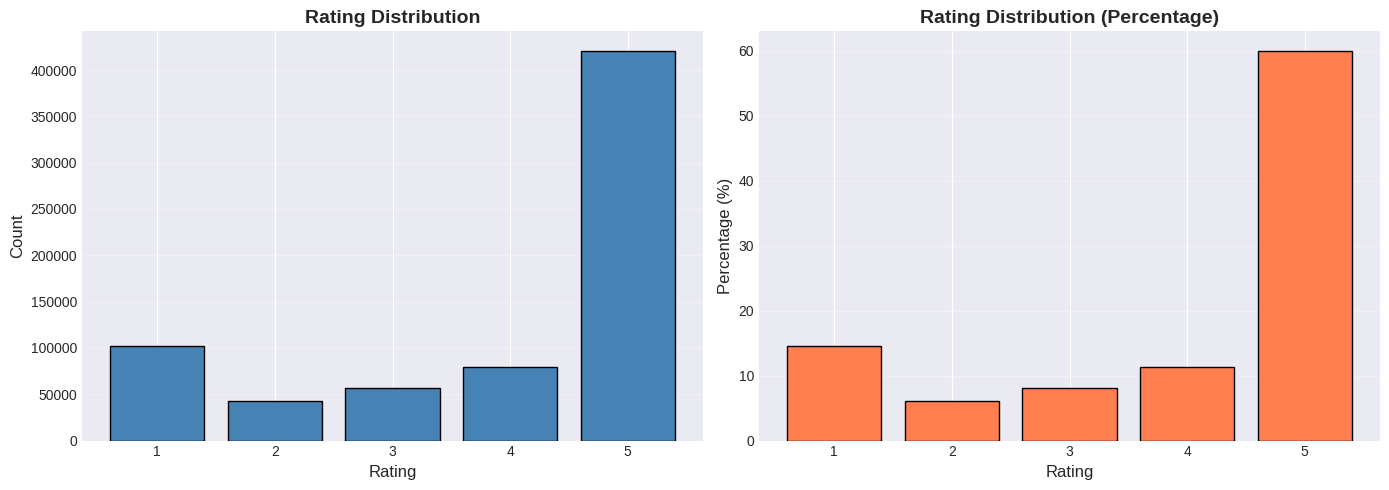

✓ Plot 1 saved


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
rating_counts = reviews_df['rating'].value_counts().sort_index()
ax[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
ax[0].set_xlabel('Rating', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

# Rating distribution (percentage)
rating_pct = (rating_counts / rating_counts.sum()) * 100
ax[1].bar(rating_pct.index, rating_pct.values, color='coral', edgecolor='black')
ax[1].set_xlabel('Rating', fontsize=12)
ax[1].set_ylabel('Percentage (%)', fontsize=12)
ax[1].set_title('Rating Distribution (Percentage)', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/01_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 1 saved")

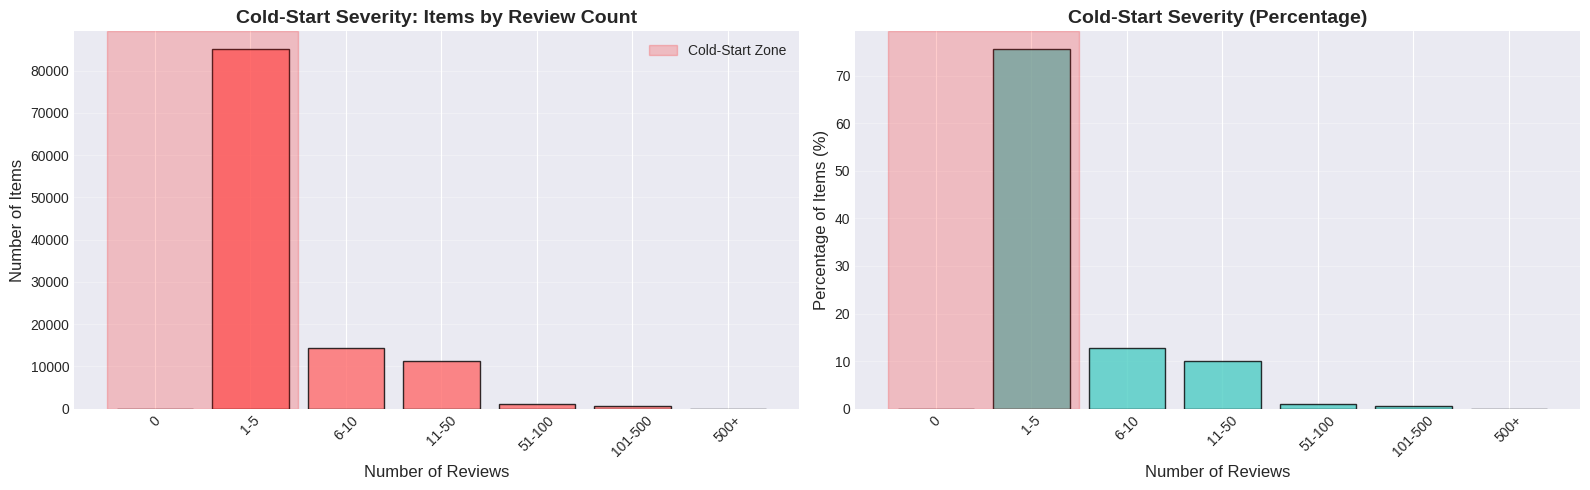

✓ Plot 2 saved

Key insight: 75.5% of items have ≤5 reviews (cold-start problem)


In [ ]:
# Review count distribution
review_counts = reviews_df['parent_asin'].value_counts()

# Create buckets
bins = [0, 1, 5, 10, 50, 100, 500, float('inf')]
labels = ['0', '1-5', '6-10', '11-50', '51-100', '101-500', '500+']
bucketed = pd.cut(review_counts, bins=bins, labels=labels, right=False)

bucket_counts = bucketed.value_counts().sort_index()
bucket_pct = (bucket_counts / bucket_counts.sum()) * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Count
ax[0].bar(range(len(bucket_counts)), bucket_counts.values,
          color='#FF6B6B', edgecolor='black', alpha=0.8)
ax[0].set_xticks(range(len(labels)))
ax[0].set_xticklabels(labels, rotation=45)
ax[0].set_xlabel('Number of Reviews', fontsize=12)
ax[0].set_ylabel('Number of Items', fontsize=12)
ax[0].set_title('Cold-Start Severity: Items by Review Count', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

# Highlight cold-start zone (≤5 reviews)
ax[0].axvspan(-0.5, 1.5, alpha=0.2, color='red', label='Cold-Start Zone')
ax[0].legend()

# Percentage
ax[1].bar(range(len(bucket_pct)), bucket_pct.values,
          color='#4ECDC4', edgecolor='black', alpha=0.8)
ax[1].set_xticks(range(len(labels)))
ax[1].set_xticklabels(labels, rotation=45)
ax[1].set_xlabel('Number of Reviews', fontsize=12)
ax[1].set_ylabel('Percentage of Items (%)', fontsize=12)
ax[1].set_title('Cold-Start Severity (Percentage)', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)
ax[1].axvspan(-0.5, 1.5, alpha=0.2, color='red')

plt.tight_layout()
plt.savefig(f'{plots_dir}/02_coldstart_severity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot 2 saved")
print(f"\nKey insight: {bucket_pct.iloc[:2].sum():.1f}% of items have ≤5 reviews (cold-start problem)")

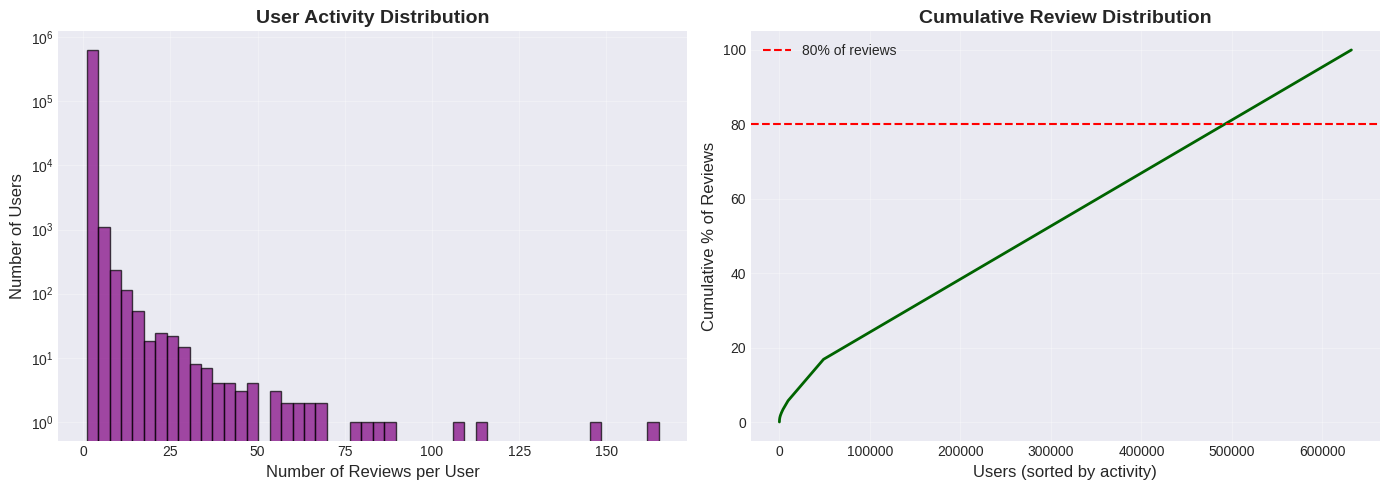

✓ Plot 3 saved

Power users: Top 10% of users contribute 18.9% of reviews


In [ ]:
user_activity = reviews_df['user_id'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax[0].hist(user_activity.values, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Number of Reviews per User', fontsize=12)
ax[0].set_ylabel('Number of Users', fontsize=12)
ax[0].set_title('User Activity Distribution', fontsize=14, fontweight='bold')
ax[0].set_yscale('log')
ax[0].grid(alpha=0.3)

# Cumulative distribution
sorted_activity = np.sort(user_activity.values)[::-1]
cumsum = np.cumsum(sorted_activity)
cumsum_pct = (cumsum / cumsum[-1]) * 100

ax[1].plot(range(len(cumsum_pct)), cumsum_pct, color='darkgreen', linewidth=2)
ax[1].axhline(y=80, color='red', linestyle='--', label='80% of reviews')
ax[1].set_xlabel('Users (sorted by activity)', fontsize=12)
ax[1].set_ylabel('Cumulative % of Reviews', fontsize=12)
ax[1].set_title('Cumulative Review Distribution', fontsize=14, fontweight='bold')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/03_user_activity.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate power user stats
top_10pct_users = int(len(user_activity) * 0.1)
top_10pct_reviews = user_activity.iloc[:top_10pct_users].sum()
top_10pct_pct = (top_10pct_reviews / n_reviews) * 100

print(f"✓ Plot 3 saved")
print(f"\nPower users: Top 10% of users contribute {top_10pct_pct:.1f}% of reviews")

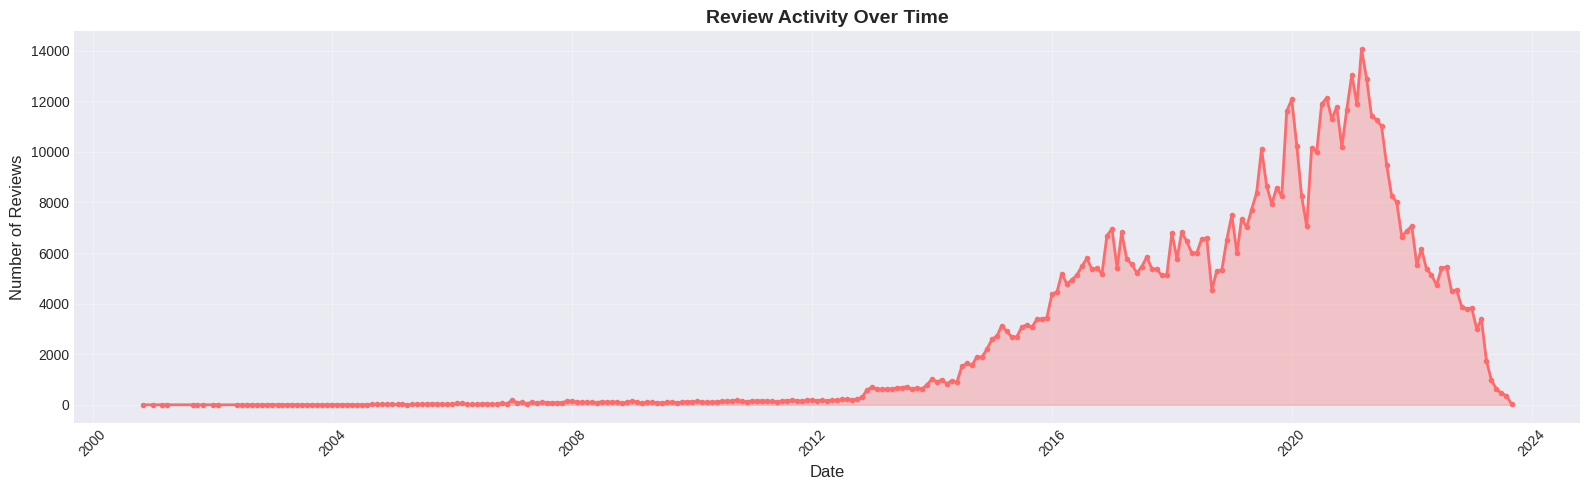

✓ Plot 4 saved


In [ ]:
# Reviews over time
reviews_df['year_month'] = reviews_df['timestamp'].dt.to_period('M')
temporal = reviews_df.groupby('year_month').size()

# Convert to datetime for plotting
temporal.index = temporal.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(temporal.index, temporal.values, linewidth=2, color='#FF6B6B', marker='o', markersize=3)
ax.fill_between(temporal.index, temporal.values, alpha=0.3, color='#FF6B6B')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Review Activity Over Time', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{plots_dir}/04_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 4 saved")

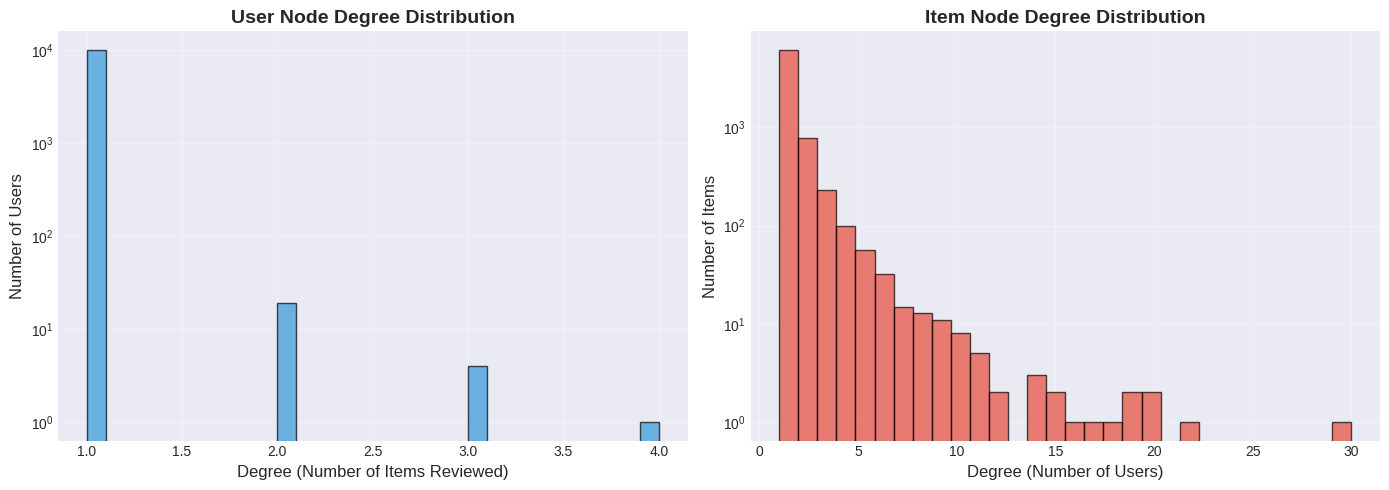

✓ Plot 5 saved
Avg user degree: 1.00
Avg item degree: 1.35


In [ ]:
# Sample 10K reviews for visualization
sample_df = reviews_df.sample(min(10000, len(reviews_df)), random_state=42)

user_degrees = sample_df['user_id'].value_counts()
item_degrees = sample_df['parent_asin'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# User degree distribution
ax[0].hist(user_degrees.values, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Degree (Number of Items Reviewed)', fontsize=12)
ax[0].set_ylabel('Number of Users', fontsize=12)
ax[0].set_title('User Node Degree Distribution', fontsize=14, fontweight='bold')
ax[0].set_yscale('log')
ax[0].grid(alpha=0.3)

# Item degree distribution
ax[1].hist(item_degrees.values, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Degree (Number of Users)', fontsize=12)
ax[1].set_ylabel('Number of Items', fontsize=12)
ax[1].set_title('Item Node Degree Distribution', fontsize=14, fontweight='bold')
ax[1].set_yscale('log')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/05_graph_connectivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 5 saved")
print(f"Avg user degree: {user_degrees.mean():.2f}")
print(f"Avg item degree: {item_degrees.mean():.2f}")

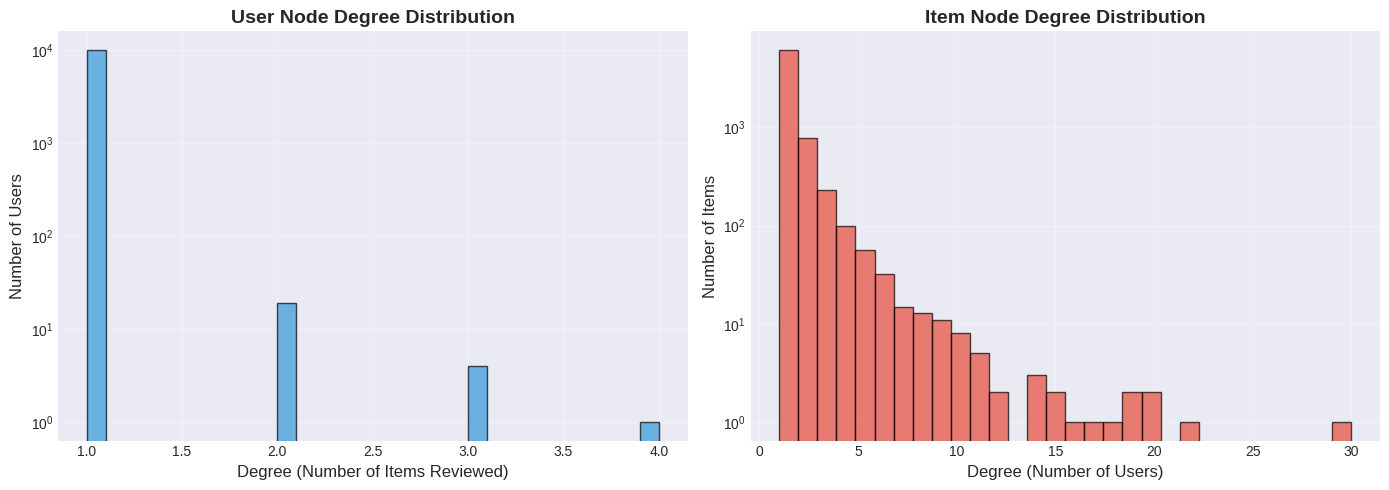

✓ Plot 5 saved
Avg user degree: 1.00
Avg item degree: 1.35


In [ ]:
# Sample 10K reviews for visualization
sample_df = reviews_df.sample(min(10000, len(reviews_df)), random_state=42)

user_degrees = sample_df['user_id'].value_counts()
item_degrees = sample_df['parent_asin'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# User degree distribution
ax[0].hist(user_degrees.values, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Degree (Number of Items Reviewed)', fontsize=12)
ax[0].set_ylabel('Number of Users', fontsize=12)
ax[0].set_title('User Node Degree Distribution', fontsize=14, fontweight='bold')
ax[0].set_yscale('log')
ax[0].grid(alpha=0.3)

# Item degree distribution
ax[1].hist(item_degrees.values, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Degree (Number of Users)', fontsize=12)
ax[1].set_ylabel('Number of Items', fontsize=12)
ax[1].set_title('Item Node Degree Distribution', fontsize=14, fontweight='bold')
ax[1].set_yscale('log')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/05_graph_connectivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 5 saved")
print(f"Avg user degree: {user_degrees.mean():.2f}")
print(f"Avg item degree: {item_degrees.mean():.2f}")

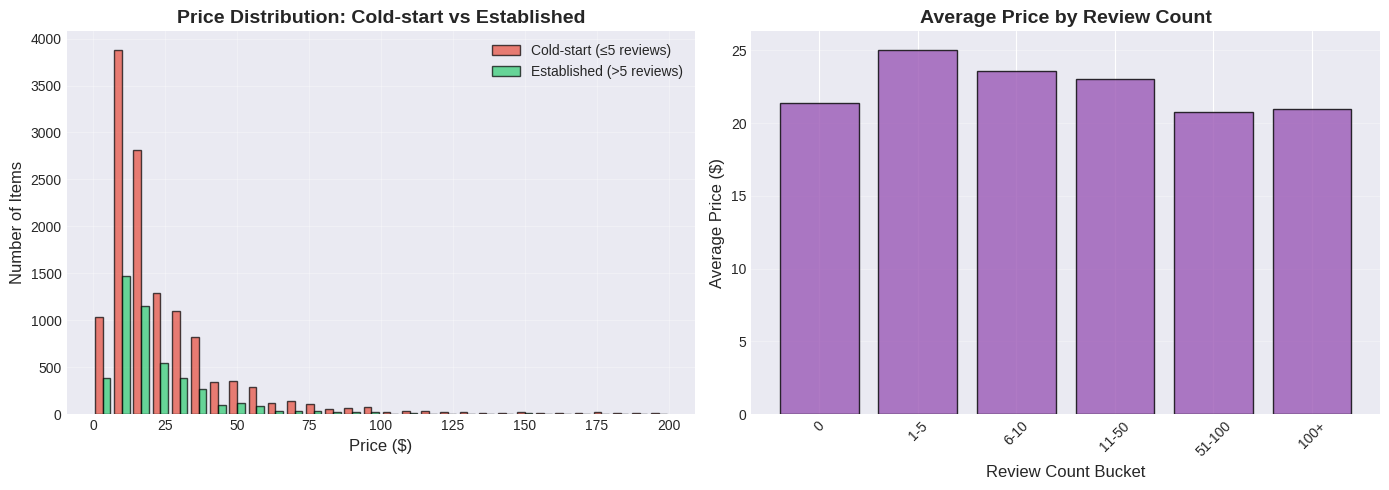

✓ Plot 6 saved
Avg price (cold-start): $24.94
Avg price (established): $23.02


In [ ]:
# Extract price from metadata
meta_df['price_clean'] = pd.to_numeric(meta_df['price'], errors='coerce')

# Merge with review counts
item_reviews = reviews_df['parent_asin'].value_counts().reset_index()
item_reviews.columns = ['parent_asin', 'review_count']

meta_with_counts = meta_df.merge(item_reviews, on='parent_asin', how='left')
meta_with_counts['review_count'] = meta_with_counts['review_count'].fillna(0)
meta_with_counts['is_coldstart'] = meta_with_counts['review_count'] <= 5

# Filter valid prices
price_df = meta_with_counts[meta_with_counts['price_clean'].notna()]
price_df = price_df[price_df['price_clean'] < 200]  # Remove outliers

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution by cold-start status
coldstart_prices = price_df[price_df['is_coldstart']]['price_clean']
established_prices = price_df[~price_df['is_coldstart']]['price_clean']

ax[0].hist([coldstart_prices, established_prices], bins=30,
           label=['Cold-start (≤5 reviews)', 'Established (>5 reviews)'],
           color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
ax[0].set_xlabel('Price ($)', fontsize=12)
ax[0].set_ylabel('Number of Items', fontsize=12)
ax[0].set_title('Price Distribution: Cold-start vs Established', fontsize=14, fontweight='bold')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Average price by review bucket
bins = [0, 1, 5, 10, 50, 100, float('inf')]
labels = ['0', '1-5', '6-10', '11-50', '51-100', '100+']
price_df['review_bucket'] = pd.cut(price_df['review_count'], bins=bins, labels=labels, right=False)

avg_prices = price_df.groupby('review_bucket')['price_clean'].mean()

ax[1].bar(range(len(avg_prices)), avg_prices.values, color='#9b59b6', edgecolor='black', alpha=0.8)
ax[1].set_xticks(range(len(labels)))
ax[1].set_xticklabels(labels, rotation=45)
ax[1].set_xlabel('Review Count Bucket', fontsize=12)
ax[1].set_ylabel('Average Price ($)', fontsize=12)
ax[1].set_title('Average Price by Review Count', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/06_price_coldstart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 6 saved")
print(f"Avg price (cold-start): ${coldstart_prices.mean():.2f}")
print(f"Avg price (established): ${established_prices.mean():.2f}")

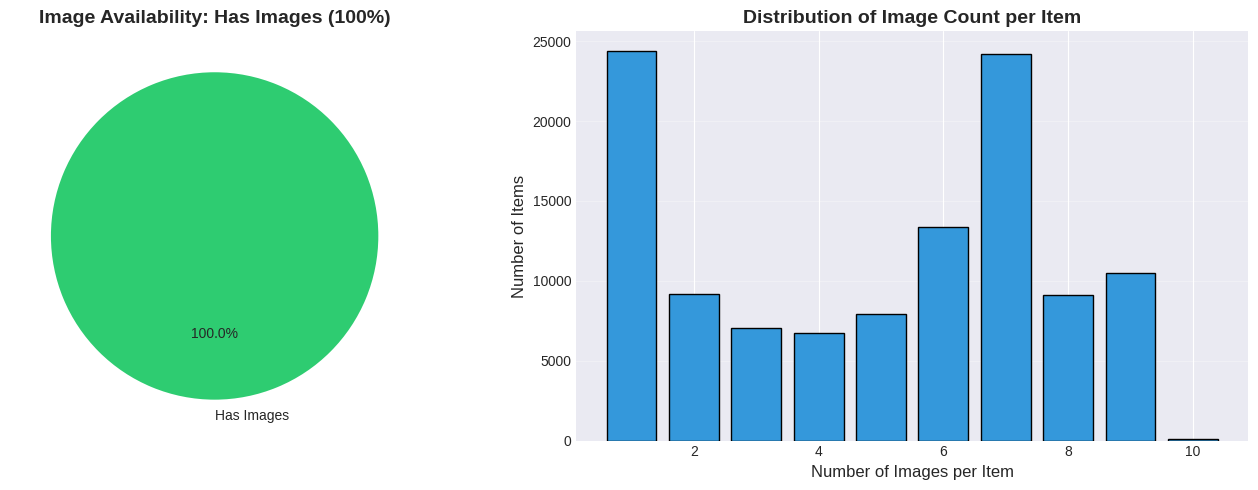

✓ Plot 7 saved
Items with images: 112,590 (100.0%)
Avg images per item: 4.88


In [ ]:
# Image availability analysis
meta_df['has_images'] = meta_df['images'].apply(lambda x: len(x) > 0 if x else False)
meta_df['num_images'] = meta_df['images'].apply(lambda x: len(x) if x else 0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Image availability - handle single category
image_avail = meta_df['has_images'].value_counts()

if len(image_avail) == 1:
    # All have images or all don't
    label = 'Has Images' if image_avail.index[0] else 'No Images'
    ax[0].pie([100], labels=[label], autopct='%1.1f%%', startangle=90, colors=['#2ecc71'])
    ax[0].set_title(f'Image Availability: {label} (100%)', fontsize=14, fontweight='bold')
else:
    # Mixed
    ax[0].pie(image_avail.values, labels=['Has Images', 'No Images'],
              autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
    ax[0].set_title('Image Availability', fontsize=14, fontweight='bold')

# Number of images distribution
image_counts = meta_df[meta_df['num_images'] > 0]['num_images'].value_counts().sort_index()
ax[1].bar(image_counts.index[:10], image_counts.values[:10], color='#3498db', edgecolor='black')
ax[1].set_xlabel('Number of Images per Item', fontsize=12)
ax[1].set_ylabel('Number of Items', fontsize=12)
ax[1].set_title('Distribution of Image Count per Item', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/07_image_availability.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 7 saved")
print(f"Items with images: {image_avail[True]:,} ({image_avail[True]/len(meta_df)*100:.1f}%)")
print(f"Avg images per item: {meta_df['num_images'].mean():.2f}")

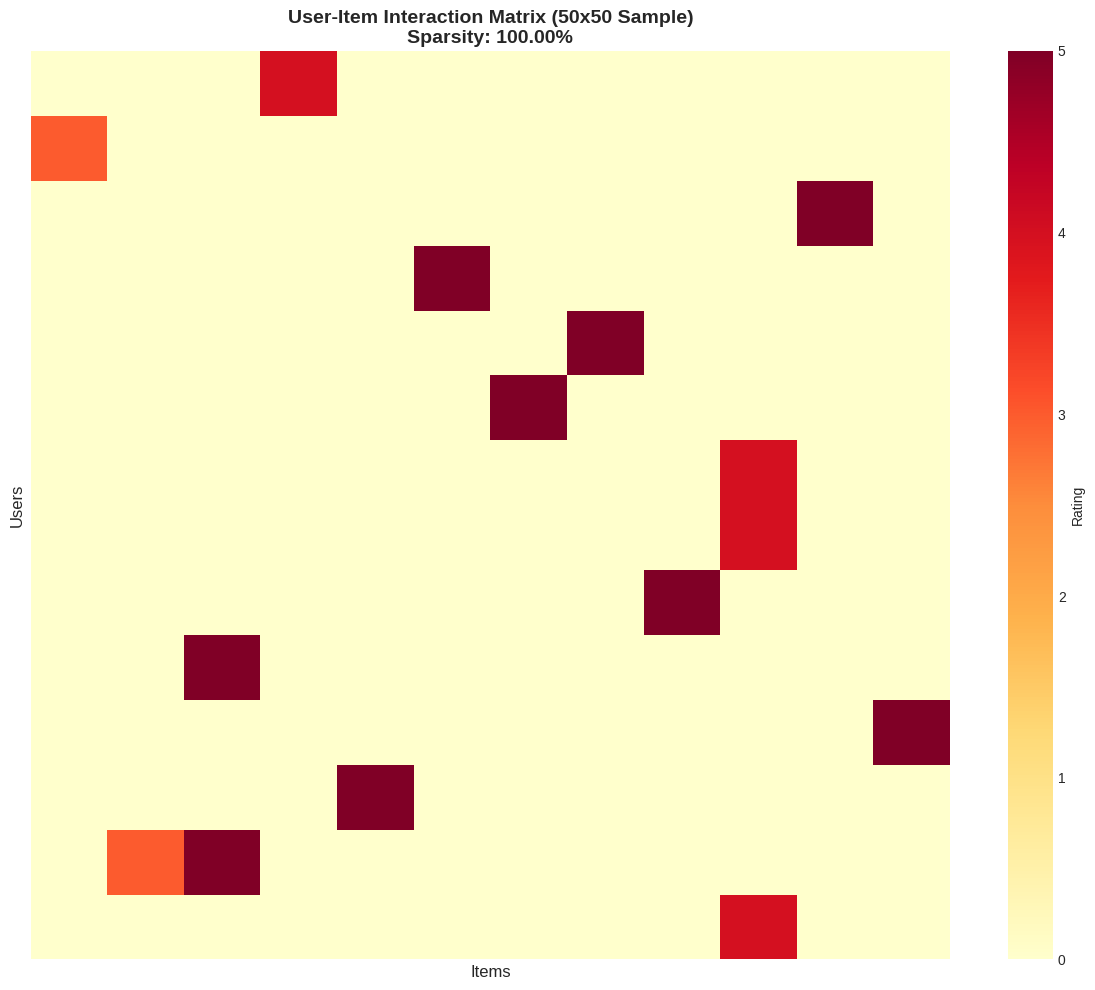

✓ Plot 8 saved


In [ ]:
# Create sparsity visualization (sample for visualization)
sample_size = 100
sample_users = reviews_df['user_id'].value_counts().head(sample_size).index
sample_items = reviews_df['parent_asin'].value_counts().head(sample_size).index

sample_interactions = reviews_df[
    (reviews_df['user_id'].isin(sample_users)) &
    (reviews_df['parent_asin'].isin(sample_items))
]

# Create interaction matrix
interaction_matrix = sample_interactions.pivot_table(
    index='user_id',
    columns='parent_asin',
    values='rating',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(interaction_matrix.iloc[:50, :50], cmap='YlOrRd', cbar_kws={'label': 'Rating'},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_xlabel('Items', fontsize=12)
ax.set_ylabel('Users', fontsize=12)
ax.set_title(f'User-Item Interaction Matrix (50x50 Sample)\nSparsity: {sparsity*100:.2f}%',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{plots_dir}/08_sparsity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 8 saved")

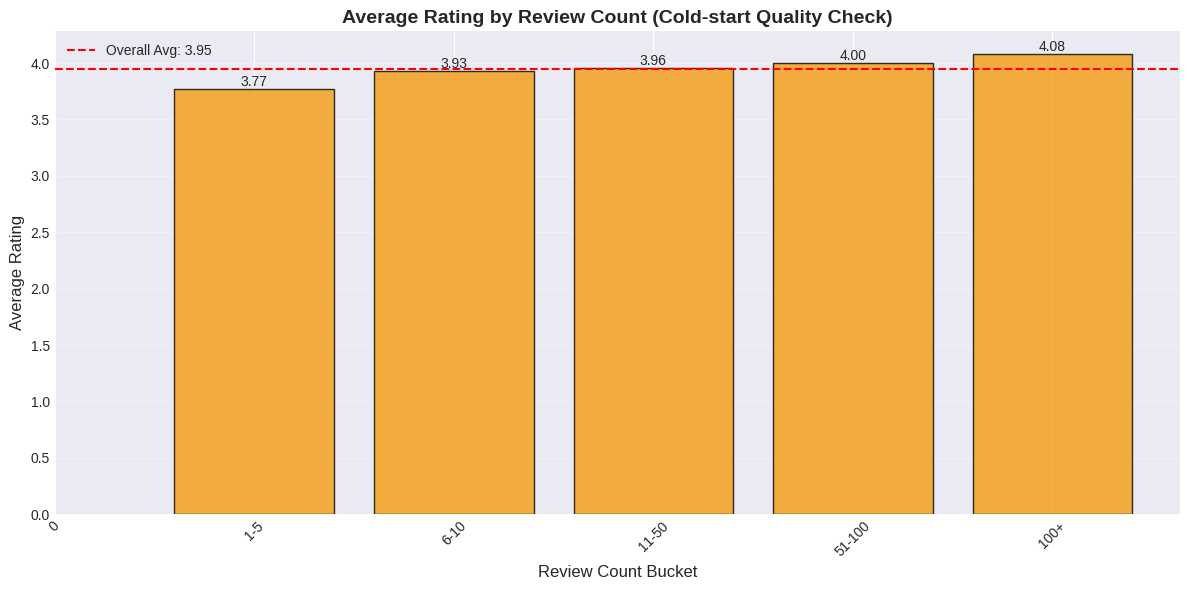

✓ Plot 9 saved

Insight: Cold-start items (≤5 reviews) have avg rating: 3.77


In [ ]:
# Average rating by review count bucket
item_stats = reviews_df.groupby('parent_asin').agg({
    'rating': 'mean',
    'parent_asin': 'count'
}).rename(columns={'parent_asin': 'review_count'})

bins = [0, 1, 5, 10, 50, 100, float('inf')]
labels = ['0', '1-5', '6-10', '11-50', '51-100', '100+']
item_stats['review_bucket'] = pd.cut(item_stats['review_count'], bins=bins, labels=labels, right=False)

avg_ratings = item_stats.groupby('review_bucket')['rating'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(avg_ratings)), avg_ratings.values, color='#f39c12', edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Review Count Bucket', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)
ax.set_title('Average Rating by Review Count (Cold-start Quality Check)', fontsize=14, fontweight='bold')
ax.axhline(y=avg_ratings.mean(), color='red', linestyle='--', label=f'Overall Avg: {avg_ratings.mean():.2f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{plots_dir}/09_rating_vs_reviewcount.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 9 saved")
print(f"\nInsight: Cold-start items (≤5 reviews) have avg rating: {avg_ratings.iloc[1]:.2f}")

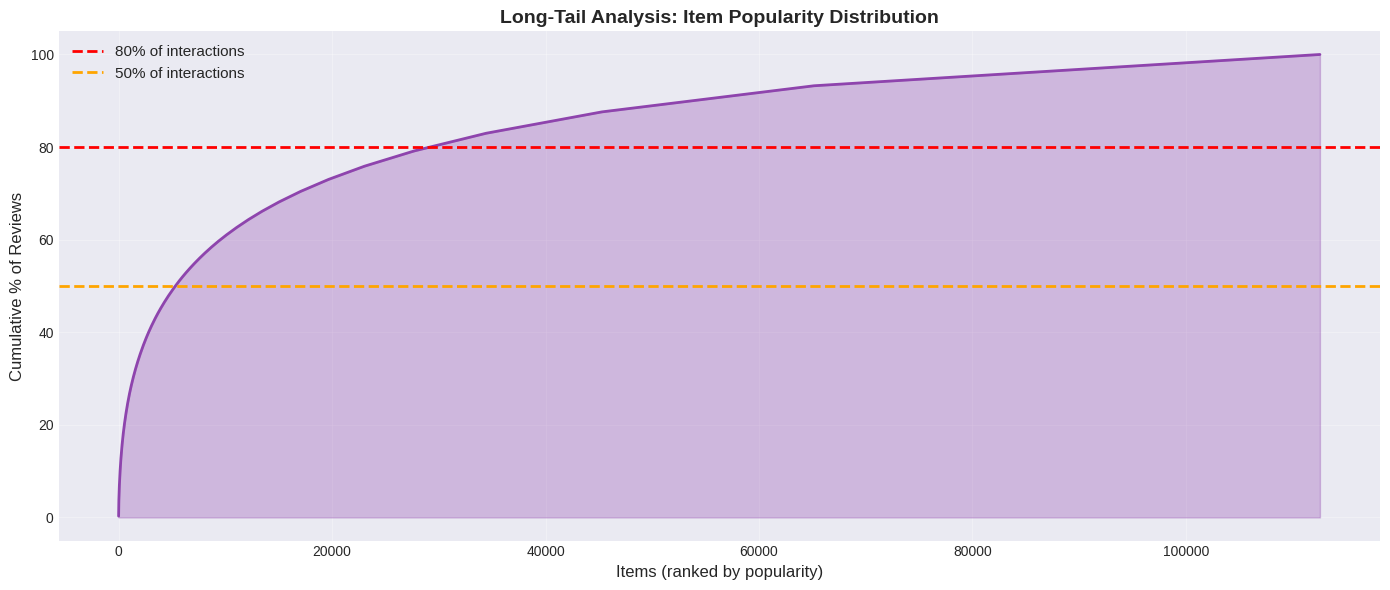

✓ Plot 10 saved

Long-tail insight: 25.9% of items account for 80% of reviews
Recommendation opportunity: 74.1% of items are under-exposed


In [ ]:
# Long-tail distribution
item_popularity = reviews_df['parent_asin'].value_counts()
sorted_popularity = item_popularity.sort_values(ascending=False).values

cumsum = np.cumsum(sorted_popularity)
cumsum_pct = (cumsum / cumsum[-1]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(cumsum_pct)), cumsum_pct, color='#8e44ad', linewidth=2)
ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% of interactions')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=2, label='50% of interactions')
ax.fill_between(range(len(cumsum_pct)), cumsum_pct, alpha=0.3, color='#8e44ad')

ax.set_xlabel('Items (ranked by popularity)', fontsize=12)
ax.set_ylabel('Cumulative % of Reviews', fontsize=12)
ax.set_title('Long-Tail Analysis: Item Popularity Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/10_longtail_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate long-tail stats
items_for_80pct = np.where(cumsum_pct >= 80)[0][0] + 1
pct_items_80 = (items_for_80pct / len(cumsum_pct)) * 100

print("✓ Plot 10 saved")
print(f"\nLong-tail insight: {pct_items_80:.1f}% of items account for 80% of reviews")
print(f"Recommendation opportunity: {100-pct_items_80:.1f}% of items are under-exposed")

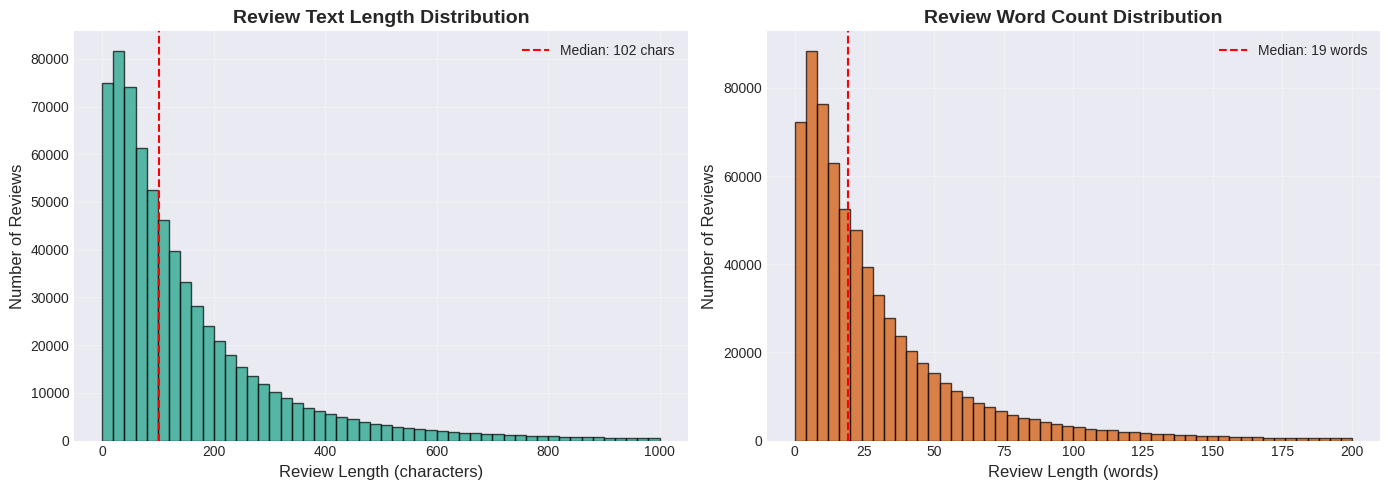

✓ Plot 11 saved
Avg review length: 173 chars, 33 words


In [ ]:
# Review text analysis
reviews_df['text_length'] = reviews_df['text'].fillna('').apply(len)
reviews_df['text_length_words'] = reviews_df['text'].fillna('').apply(lambda x: len(x.split()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Character length
ax[0].hist(reviews_df['text_length'], bins=50, color='#16a085', edgecolor='black', alpha=0.7, range=(0, 1000))
ax[0].set_xlabel('Review Length (characters)', fontsize=12)
ax[0].set_ylabel('Number of Reviews', fontsize=12)
ax[0].set_title('Review Text Length Distribution', fontsize=14, fontweight='bold')
ax[0].axvline(reviews_df['text_length'].median(), color='red', linestyle='--',
              label=f'Median: {reviews_df["text_length"].median():.0f} chars')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Word count
ax[1].hist(reviews_df['text_length_words'], bins=50, color='#d35400', edgecolor='black', alpha=0.7, range=(0, 200))
ax[1].set_xlabel('Review Length (words)', fontsize=12)
ax[1].set_ylabel('Number of Reviews', fontsize=12)
ax[1].set_title('Review Word Count Distribution', fontsize=14, fontweight='bold')
ax[1].axvline(reviews_df['text_length_words'].median(), color='red', linestyle='--',
              label=f'Median: {reviews_df["text_length_words"].median():.0f} words')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/11_review_length.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 11 saved")
print(f"Avg review length: {reviews_df['text_length'].mean():.0f} chars, {reviews_df['text_length_words'].mean():.0f} words")

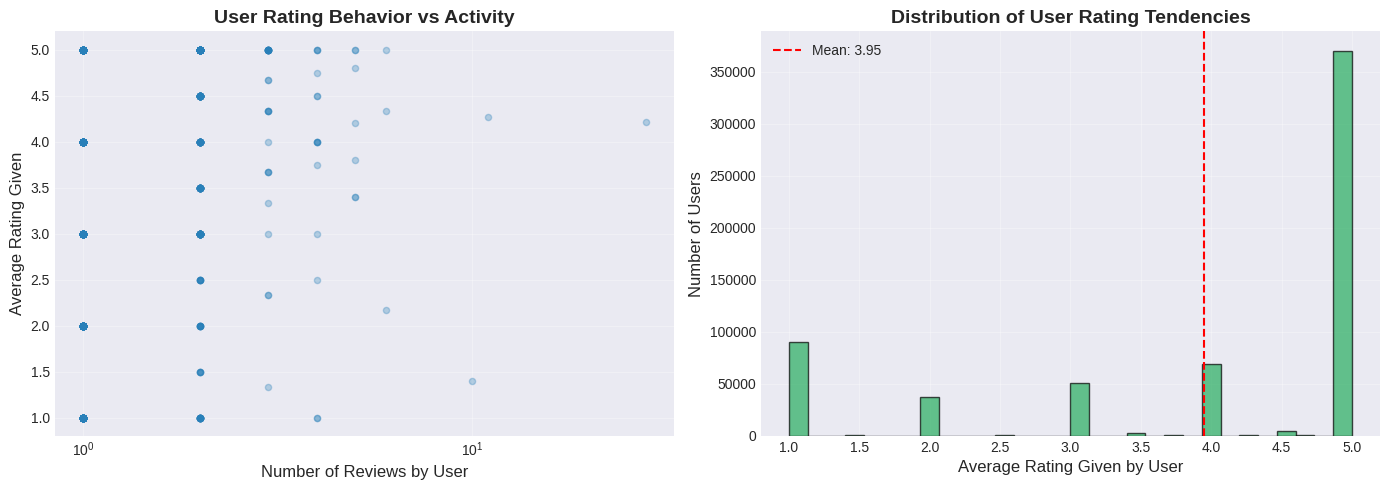

✓ Plot 12 saved


In [ ]:
# User behavior patterns
user_stats = reviews_df.groupby('user_id').agg({
    'rating': 'mean',
    'parent_asin': 'count'
}).rename(columns={'parent_asin': 'num_reviews'})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Average rating given by user vs their activity
scatter_sample = user_stats.sample(min(5000, len(user_stats)), random_state=42)
ax[0].scatter(scatter_sample['num_reviews'], scatter_sample['rating'],
              alpha=0.3, s=20, color='#2980b9')
ax[0].set_xlabel('Number of Reviews by User', fontsize=12)
ax[0].set_ylabel('Average Rating Given', fontsize=12)
ax[0].set_title('User Rating Behavior vs Activity', fontsize=14, fontweight='bold')
ax[0].set_xscale('log')
ax[0].grid(alpha=0.3)

# Distribution of user average ratings
ax[1].hist(user_stats['rating'], bins=30, color='#27ae60', edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Average Rating Given by User', fontsize=12)
ax[1].set_ylabel('Number of Users', fontsize=12)
ax[1].set_title('Distribution of User Rating Tendencies', fontsize=14, fontweight='bold')
ax[1].axvline(user_stats['rating'].mean(), color='red', linestyle='--',
              label=f'Mean: {user_stats["rating"].mean():.2f}')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/12_user_behavior.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 12 saved")

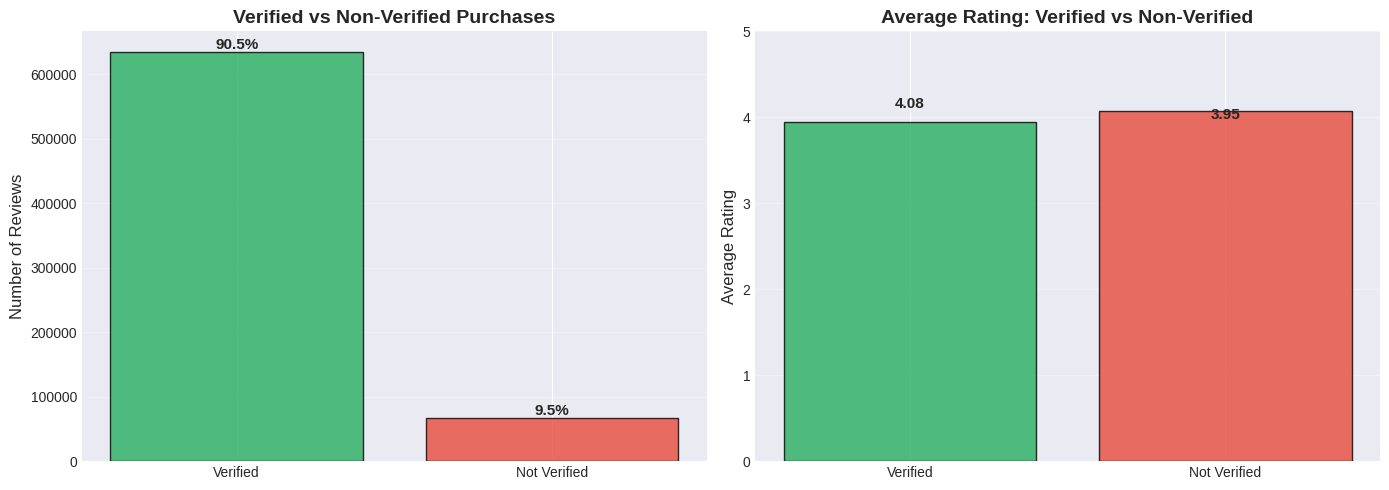

✓ Plot 13 saved


In [ ]:
# Verified purchase analysis
verified_stats = reviews_df.groupby('verified_purchase').agg({
    'rating': ['mean', 'count']
}).round(2)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count
verified_counts = reviews_df['verified_purchase'].value_counts()
ax[0].bar(['Verified', 'Not Verified'],
          [verified_counts.get(True, 0), verified_counts.get(False, 0)],
          color=['#27ae60', '#e74c3c'], edgecolor='black', alpha=0.8)
ax[0].set_ylabel('Number of Reviews', fontsize=12)
ax[0].set_title('Verified vs Non-Verified Purchases', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

# Add percentages
for i, (label, val) in enumerate(verified_counts.items()):
    pct = (val / verified_counts.sum()) * 100
    ax[0].text(i, val, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Average rating comparison
verified_ratings = reviews_df.groupby('verified_purchase')['rating'].mean()
ax[1].bar(['Verified', 'Not Verified'],
          [verified_ratings.get(True, 0), verified_ratings.get(False, 0)],
          color=['#27ae60', '#e74c3c'], edgecolor='black', alpha=0.8)
ax[1].set_ylabel('Average Rating', fontsize=12)
ax[1].set_title('Average Rating: Verified vs Non-Verified', fontsize=14, fontweight='bold')
ax[1].set_ylim([0, 5])
ax[1].grid(axis='y', alpha=0.3)

# Add values
for i, (label, val) in enumerate(verified_ratings.items()):
    ax[1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{plots_dir}/13_verified_purchase.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 13 saved")

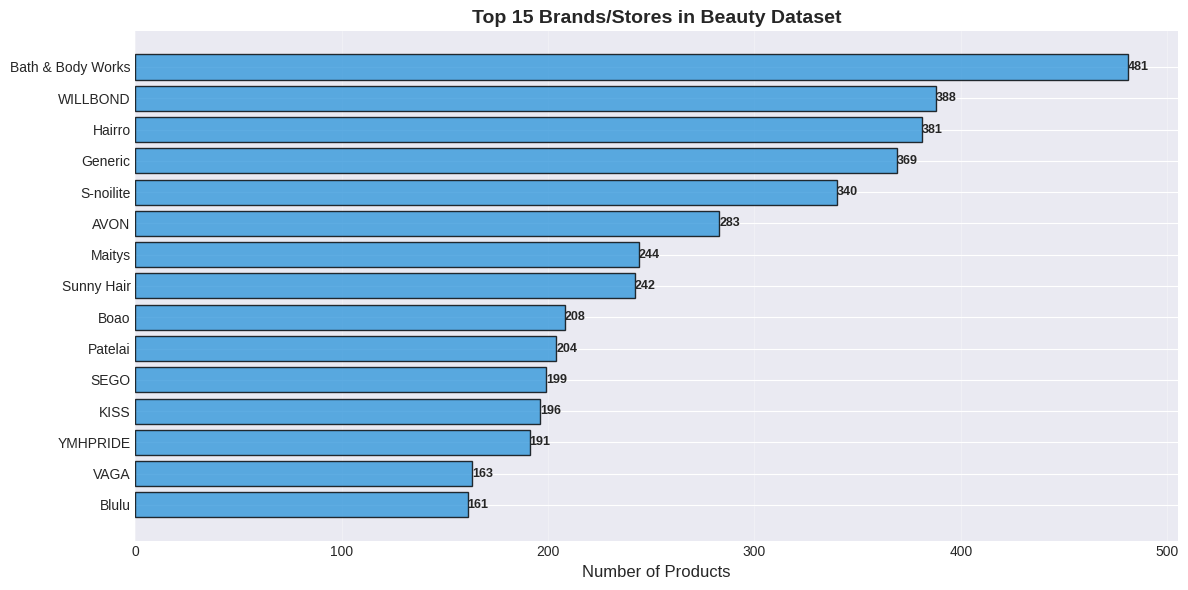

✓ Plot 14 saved


In [ ]:
# Extract top stores/brands from metadata
top_stores = meta_df['store'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_stores)), top_stores.values, color='#3498db', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_stores)))
ax.set_yticklabels(top_stores.index, fontsize=10)
ax.set_xlabel('Number of Products', fontsize=12)
ax.set_title('Top 15 Brands/Stores in Beauty Dataset', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{plots_dir}/14_top_brands.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 14 saved")

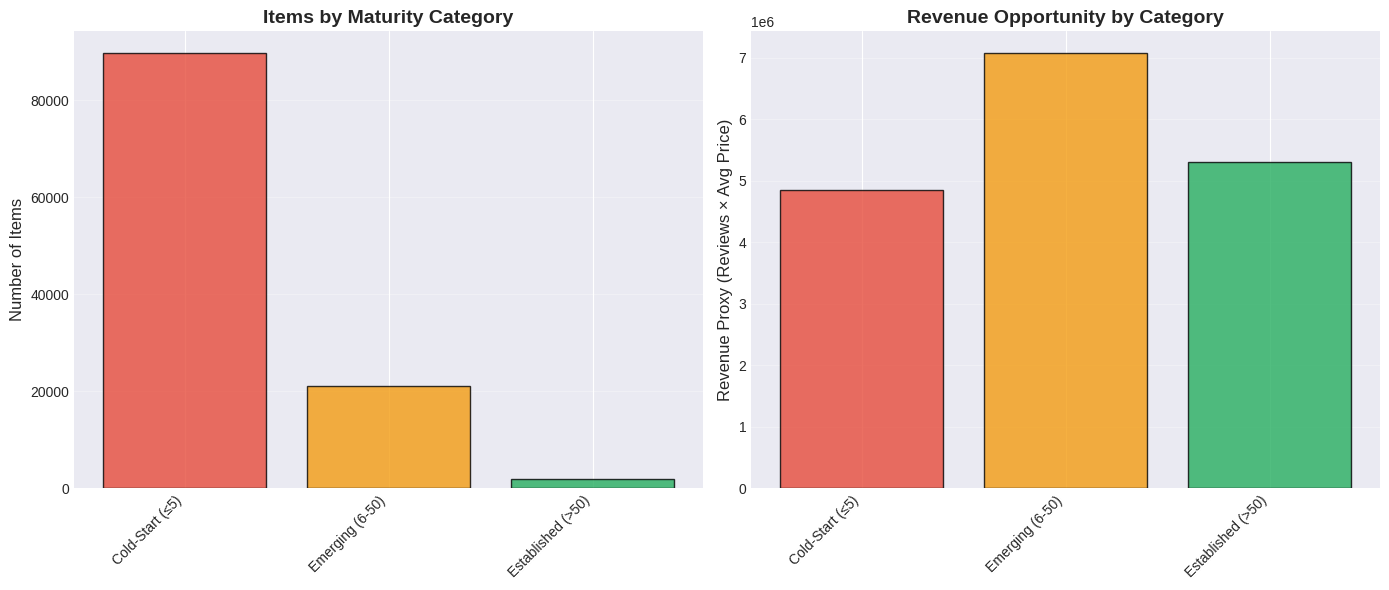

✓ Plot 15 saved

Business Impact:
Cold-start items: 89,699 (79.7%)
Revenue opportunity: Improve cold-start recommendations → unlock hidden inventory value


In [ ]:
# Business impact estimation
item_stats_business = reviews_df.groupby('parent_asin').agg({
    'parent_asin': 'count',
    'rating': 'mean'
}).rename(columns={'parent_asin': 'review_count'})

# Merge with price data
item_stats_business = item_stats_business.merge(
    meta_df[['parent_asin', 'price']].set_index('parent_asin'),
    left_index=True, right_index=True, how='left'
)
item_stats_business['price'] = pd.to_numeric(item_stats_business['price'], errors='coerce')

# Categorize
item_stats_business['category'] = pd.cut(
    item_stats_business['review_count'],
    bins=[0, 5, 50, float('inf')],
    labels=['Cold-Start (≤5)', 'Emerging (6-50)', 'Established (>50)']
)

# Calculate revenue proxy
category_stats = item_stats_business.groupby('category').agg({
    'review_count': 'sum',
    'price': 'mean'
}).dropna()

category_counts = item_stats_business['category'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Number of items
ax[0].bar(range(len(category_counts)), category_counts.values,
          color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black', alpha=0.8)
ax[0].set_xticks(range(len(category_counts)))
ax[0].set_xticklabels(category_counts.index, rotation=45, ha='right')
ax[0].set_ylabel('Number of Items', fontsize=12)
ax[0].set_title('Items by Maturity Category', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

# Revenue opportunity (proxy)
revenue_proxy = category_stats['review_count'] * category_stats['price']
ax[1].bar(range(len(revenue_proxy)), revenue_proxy.values,
          color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black', alpha=0.8)
ax[1].set_xticks(range(len(revenue_proxy)))
ax[1].set_xticklabels(revenue_proxy.index, rotation=45, ha='right')
ax[1].set_ylabel('Revenue Proxy (Reviews × Avg Price)', fontsize=12)
ax[1].set_title('Revenue Opportunity by Category', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/15_business_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 15 saved")
print(f"\nBusiness Impact:")
print(f"Cold-start items: {category_counts.iloc[0]:,} ({category_counts.iloc[0]/category_counts.sum()*100:.1f}%)")
print(f"Revenue opportunity: Improve cold-start recommendations → unlock hidden inventory value")

In [ ]:
# Save processed data for next phases
print("Saving processed data...")

# Sample dataset for development (10K users, manageable size)
sample_users = reviews_df['user_id'].value_counts().head(10000).index
sample_df = reviews_df[reviews_df['user_id'].isin(sample_users)].copy()

# Get relevant items
sample_items = sample_df['parent_asin'].unique()
sample_meta = meta_df[meta_df['parent_asin'].isin(sample_items)].copy()

# Save
import pickle

data_to_save = {
    'reviews': sample_df,
    'metadata': sample_meta,
    'stats': stats
}

with open(f'{output_dir}/processed_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"✓ Processed data saved: {output_dir}/processed_data.pkl")
print(f"  - Reviews: {len(sample_df):,}")
print(f"  - Users: {sample_df['user_id'].nunique():,}")
print(f"  - Items: {sample_df['parent_asin'].nunique():,}")
print(f"  - File size: {os.path.getsize(f'{output_dir}/processed_data.pkl') / 1024**2:.2f} MB")

Saving processed data...
✓ Processed data saved: /content/drive/MyDrive/CSE 941/outputs/phase1/processed_data.pkl
  - Reviews: 41,109
  - Users: 10,000
  - Items: 20,223
  - File size: 58.35 MB


In [ ]:
import time
from datetime import datetime

print("\n" + "="*70)
print("PHASE 1 COMPLETE - FINAL REPORT")
print("="*70)
print(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

print("\n📊 DATASET STATISTICS:")
for key, value in stats.items():
    print(f"  {key:.<45} {value}")

print("\n📈 EDA OUTPUTS:")
plot_files = sorted([f for f in os.listdir(plots_dir) if f.endswith('.png')])
print(f"  Total plots generated: {len(plot_files)}")
for i, plot in enumerate(plot_files, 1):
    print(f"    {i:2d}. {plot}")

print("\n💾 SAVED ARTIFACTS:")
print(f"  ✓ Processed data: {output_dir}/processed_data.pkl")
print(f"  ✓ Statistics JSON: {output_dir}/dataset_stats.json")
print(f"  ✓ EDA plots: {plots_dir}/ ({len(plot_files)} files)")

print("\n🎯 KEY INSIGHTS:")
print(f"  • Cold-start severity: {cold_start_pct:.1f}% of items have ≤5 reviews")
print(f"  • Long-tail effect: {pct_items_80:.1f}% items account for 80% of activity")
print(f"  • Image coverage: {image_coverage:.1f}% of items have product images")
print(f"  • Data sparsity: {sparsity*100:.2f}% (typical for recommendation systems)")

print("\n📂 OUTPUT LOCATION:")
print(f"  {output_dir}")

print("\n✅ READY FOR PHASE 2: Computer Vision (CLIP Embeddings)")
print("="*70)


PHASE 1 COMPLETE - FINAL REPORT
Completion Time: 2026-01-23 02:31:56

📊 DATASET STATISTICS:
  Dataset...................................... Amazon Beauty
  Total Users.................................. 631,986
  Total Items.................................. 112,565
  Total Reviews................................ 701,528
  Sparsity..................................... 100.00%
  Cold-start Items (≤5 reviews)................ 89,699 (79.7%)
  Items with Images............................ 112,590 (100.0%)
  Date Range................................... 2000-11-01 to 2023-09-09
  Avg Reviews per User......................... 1.11
  Avg Reviews per Item......................... 6.23

📈 EDA OUTPUTS:
  Total plots generated: 15
     1. 01_rating_distribution.png
     2. 02_coldstart_severity.png
     3. 03_user_activity.png
     4. 04_temporal_patterns.png
     5. 05_graph_connectivity.png
     6. 06_price_coldstart.png
     7. 07_image_availability.png
     8. 08_sparsity_heatmap.png
     9. 